# Week 7 - Milestone One week

# 1. Lesson: no lesson this week.  Milestone One is due!

# 2. Weekly graph question

Below are the graphs from last week's weekly graph question.  Suppose you wanted to cause the viewer to examine the last three months of data first.  How could you use preattentive attributes to do that?  Suggest several possibilities.

To draw attention to the last three months first, I would highlight them using preattentive attributes such as color, size, and contrast. For example, I could make the earlier months light gray and use a bold color for the final three months, increase the marker size for those points, or add a shaded background behind that section. I could also label the final three months directly so the viewer’s eye is guided there immediately.

In [3]:
import numpy as np
import seaborn as sns
import pandas as pd

In [4]:
numdates = 12
np.random.seed(0)
time_series = 100 * (np.random.normal(size = numdates) / 5 + np.arange(numdates) / 16)
datearray = pd.date_range(start='2023/01/01', end='2024/01/01', freq='M')
ax = sns.lineplot(x = datearray, y = time_series)
ax.set_xlabel("Year and month")
ax.set_ylabel("Nitrate level (% of eutrophic value)")

ValueError: Invalid frequency: M. Failed to parse with error message: ValueError("'M' is no longer supported for offsets. Please use 'ME' instead.")

Text(0, 0.5, 'Phosphate level (% of eutrophic value)')

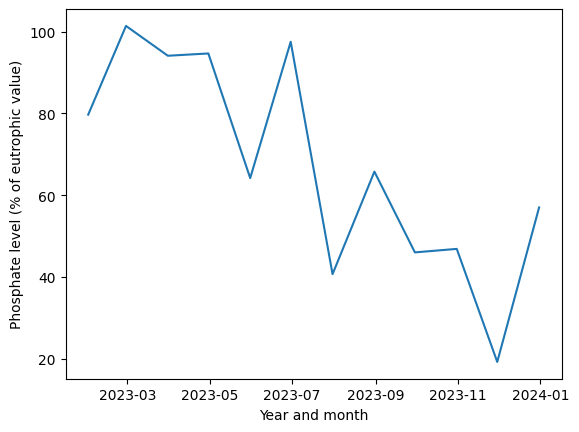

In [ ]:
np.random.seed(1)
time_series = 100 * (1 - (np.random.normal(size = numdates) / 8 + np.arange(numdates) / 16))
datearray = pd.date_range(start='2023/01/01', end='2024/01/01', freq='M')
ax = sns.lineplot(x = datearray, y = time_series)
ax.set_xlabel("Year and month")
ax.set_ylabel("Phosphate level (% of eutrophic value)")

# 3. Working on your datasets

This week, you can work on Milestone One rather than having a particular exercise about working on your datasets

In [4]:
# Install dependencies if needed
# pip install kagglehub[pandas-datasets]

import kagglehub
from kagglehub import KaggleDatasetAdapter

# Choose the small transaction dataset file
file_path = "HI-Small_Trans.csv"

df = kagglehub.load_dataset(
    KaggleDatasetAdapter.PANDAS,
    "ealtman2019/ibm-transactions-for-anti-money-laundering-aml",
    file_path
)

print("Shape:", df.shape)
print("First 5 records:")
print(df.head())

/home/codespace/.python/current/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/tmp/ipykernel_53665/1189827075.py:10: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


100%|██████████| 454M/454M [00:14<00:00, 32.9MB/s] 


Shape: (5078345, 11)
First 5 records:
          Timestamp  From Bank    Account  To Bank  Account.1  \
0  2022/09/01 00:20         10  8000EBD30       10  8000EBD30   
1  2022/09/01 00:20       3208  8000F4580        1  8000F5340   
2  2022/09/01 00:00       3209  8000F4670     3209  8000F4670   
3  2022/09/01 00:02         12  8000F5030       12  8000F5030   
4  2022/09/01 00:06         10  8000F5200       10  8000F5200   

   Amount Received Receiving Currency  Amount Paid Payment Currency  \
0          3697.34          US Dollar      3697.34        US Dollar   
1             0.01          US Dollar         0.01        US Dollar   
2         14675.57          US Dollar     14675.57        US Dollar   
3          2806.97          US Dollar      2806.97        US Dollar   
4         36682.97          US Dollar     36682.97        US Dollar   

  Payment Format  Is Laundering  
0   Reinvestment              0  
1         Cheque              0  
2   Reinvestment              0  
3   Rein

In [5]:
# clean column names first
df.columns = (
    df.columns.str.strip()
              .str.replace(" ", "_")
              .str.replace(".", "_", regex=False)
              .str.replace("/", "_", regex=False)
              .str.replace("-", "_", regex=False)
)

print(df.columns.tolist())

['Timestamp', 'From_Bank', 'Account', 'To_Bank', 'Account_1', 'Amount_Received', 'Receiving_Currency', 'Amount_Paid', 'Payment_Currency', 'Payment_Format', 'Is_Laundering']


In [6]:
# preprocessing checks
print("Shape:", df.shape)
print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

print("\nData types:")
print(df.dtypes)

Shape: (5078345, 11)

Missing values:
Timestamp             0
From_Bank             0
Account               0
To_Bank               0
Account_1             0
Amount_Received       0
Receiving_Currency    0
Amount_Paid           0
Payment_Currency      0
Payment_Format        0
Is_Laundering         0
dtype: int64

Duplicate rows: 9

Data types:
Timestamp                 str
From_Bank               int64
Account                   str
To_Bank                 int64
Account_1                 str
Amount_Received       float64
Receiving_Currency        str
Amount_Paid           float64
Payment_Currency          str
Payment_Format            str
Is_Laundering           int64
dtype: object


In [7]:
# basic summaries
display(df.describe(include="all").transpose())

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Timestamp,5078345,15018,2022/09/01 00:04,11193,NaN,NaN,NaN,NaN,NaN,NaN,NaN
From_Bank,5078345.0,NaN,NaN,NaN,45730.565729,81765.622281,1.0,119.0,9679.0,28628.0,356303.0
Account,5078345,496995,100428660,168672,NaN,NaN,NaN,NaN,NaN,NaN,NaN
To_Bank,5078345.0,NaN,NaN,NaN,65744.562853,84092.990137,1.0,4259.0,21568.0,122332.0,356294.0
Account_1,5078345,420636,100428660,1084,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Amount_Received,5078345.0,NaN,NaN,NaN,5988726.070073,1037183108.891989,0.000001,183.37,1411.01,12346.27,1046302363293.47998
Receiving_Currency,5078345,15,US Dollar,1879341,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Amount_Paid,5078345.0,NaN,NaN,NaN,4509273.367741,869772830.919865,0.000001,184.48,1414.54,12297.84,1046302363293.47998
Payment_Currency,5078345,15,US Dollar,1895172,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Payment_Format,5078345,7,Cheque,1864331,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [8]:
# class balance
print(df["Is_Laundering"].value_counts())
print(df["Is_Laundering"].value_counts(normalize=True) * 100)

Is_Laundering
0    5073168
1       5177
Name: count, dtype: int64
Is_Laundering
0    99.898057
1     0.101943
Name: proportion, dtype: float64


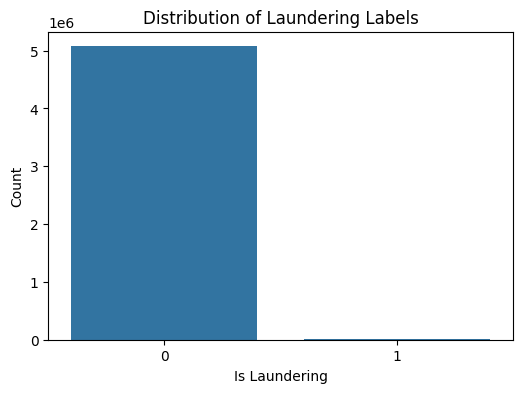

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.countplot(x="Is_Laundering", data=df)
plt.title("Distribution of Laundering Labels")
plt.xlabel("Is Laundering")
plt.ylabel("Count")
plt.show()

In [10]:
# sample for plotting so notebook stays responsive
sample_df = df.sample(n=100000, random_state=42)

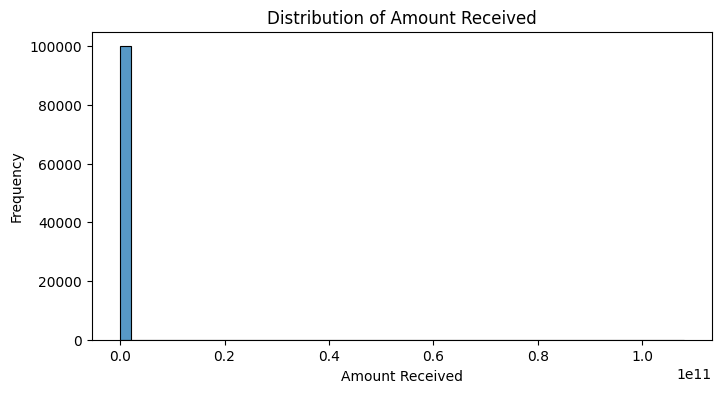

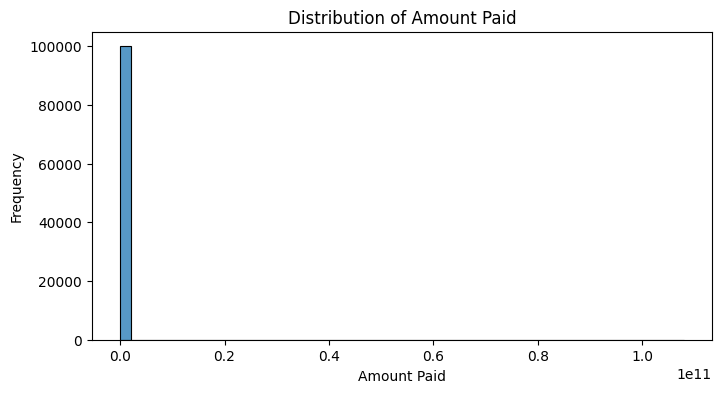

In [11]:
# transaction amount distributions
plt.figure(figsize=(8,4))
sns.histplot(sample_df["Amount_Received"], bins=50)
plt.title("Distribution of Amount Received")
plt.xlabel("Amount Received")
plt.ylabel("Frequency")
plt.show()

plt.figure(figsize=(8,4))
sns.histplot(sample_df["Amount_Paid"], bins=50)
plt.title("Distribution of Amount Paid")
plt.xlabel("Amount Paid")
plt.ylabel("Frequency")
plt.show()

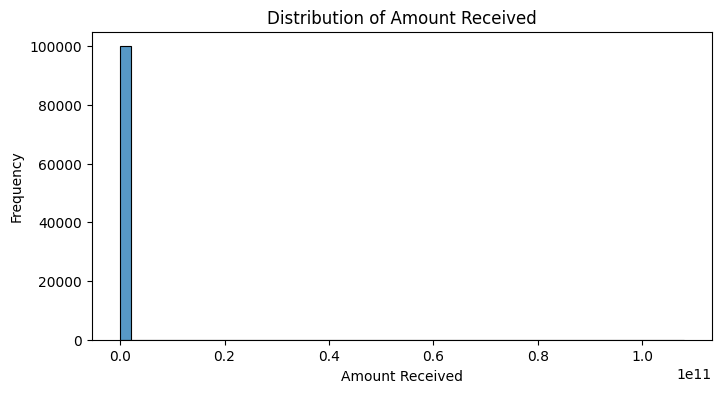

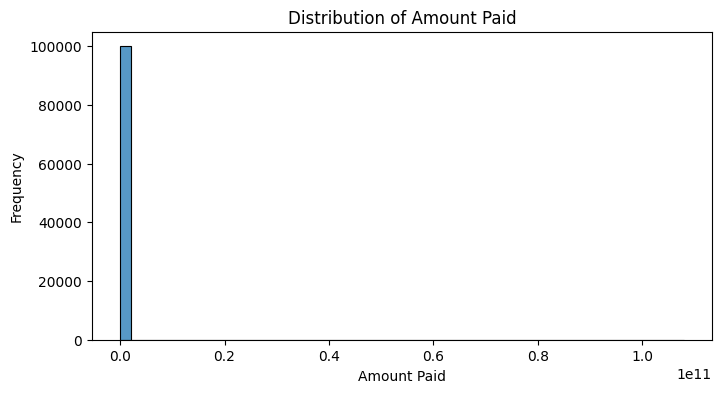

In [13]:
# transaction amount distributions
plt.figure(figsize=(8,4))
sns.histplot(sample_df["Amount_Received"], bins=50)
plt.title("Distribution of Amount Received")
plt.xlabel("Amount Received")
plt.ylabel("Frequency")
plt.show()

plt.figure(figsize=(8,4))
sns.histplot(sample_df["Amount_Paid"], bins=50)
plt.title("Distribution of Amount Paid")
plt.xlabel("Amount Paid")
plt.ylabel("Frequency")
plt.show()

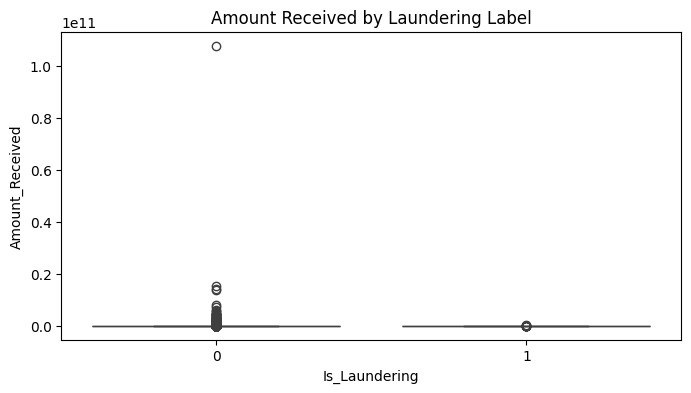

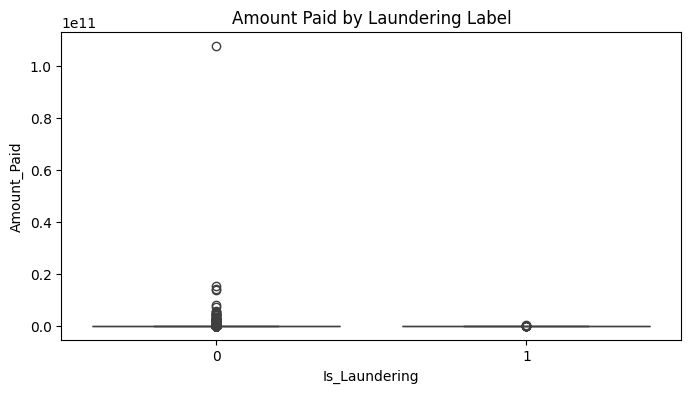

In [14]:
# compare amounts by laundering label
plt.figure(figsize=(8,4))
sns.boxplot(x="Is_Laundering", y="Amount_Received", data=sample_df)
plt.title("Amount Received by Laundering Label")
plt.show()

plt.figure(figsize=(8,4))
sns.boxplot(x="Is_Laundering", y="Amount_Paid", data=sample_df)
plt.title("Amount Paid by Laundering Label")
plt.show()

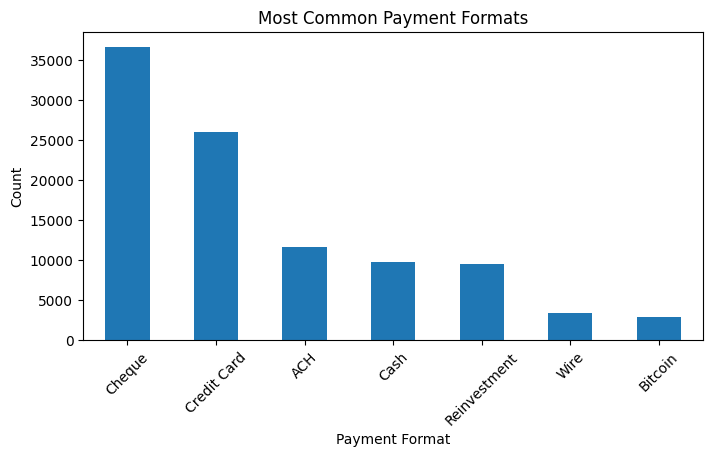

In [15]:
# most common payment formats
plt.figure(figsize=(8,4))
sample_df["Payment_Format"].value_counts().head(10).plot(kind="bar")
plt.title("Most Common Payment Formats")
plt.xlabel("Payment Format")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

Is_Laundering,0,1
Payment_Format,,
ACH,11606,88
Bitcoin,2878,2
Cash,9793,2
Cheque,36680,9
Credit Card,25968,4
Reinvestment,9536,0
Wire,3434,0


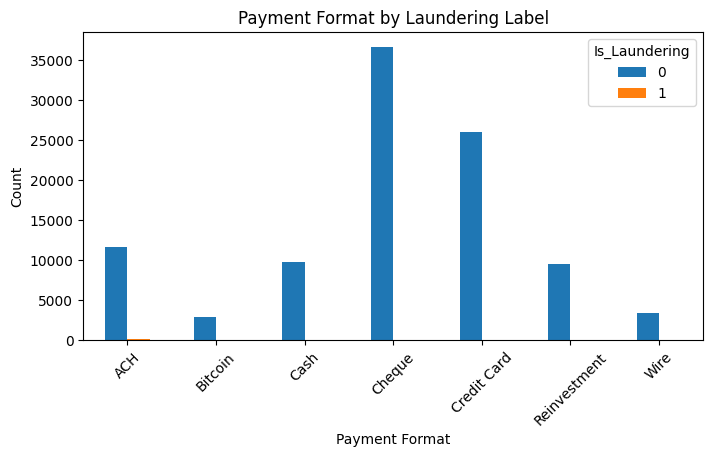

In [16]:
# laundering by payment format
payment_laundering = pd.crosstab(sample_df["Payment_Format"], sample_df["Is_Laundering"])
display(payment_laundering)

payment_laundering.plot(kind="bar", figsize=(8,4))
plt.title("Payment Format by Laundering Label")
plt.xlabel("Payment Format")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

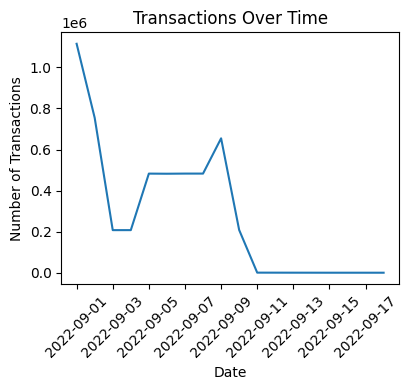

In [27]:
# timestamp analysis
df["Timestamp"] = pd.to_datetime(df["Timestamp"], errors="coerce")

tx_per_day = df.groupby(df["Timestamp"].dt.date).size()

plt.figure(figsize=(4.2,4))
tx_per_day.plot()

plt.title("Transactions Over Time")
plt.xlabel("Date")
plt.ylabel("Number of Transactions")

plt.xticks(rotation=45)        # rotate dates so they don't overlap
plt.tight_layout()             # adjust spacing

plt.savefig("figure7_transactions_over_time.png", dpi=300, bbox_inches="tight")

plt.show()

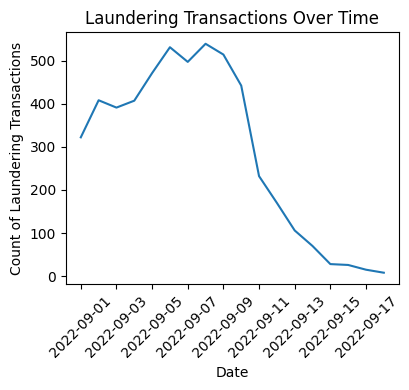

In [25]:
# laundering over time
laundering_per_day = df.groupby(df["Timestamp"].dt.date)["Is_Laundering"].sum()

plt.figure(figsize=(4.2,4))

laundering_per_day.plot()

plt.title("Laundering Transactions Over Time")
plt.xlabel("Date")
plt.ylabel("Count of Laundering Transactions")

plt.xticks(rotation=45)   # fix overlapping dates
plt.tight_layout()

plt.savefig("figure8_laundering_over_time.png", dpi=300, bbox_inches="tight")

plt.show()

# 4. Storytelling With Data plot

Reproduce any graph of your choice in p. 99-119 of the Storytelling With Data book as best you can. (The first half of chapter four). You do not have to get the exact data values right, just the overall look and feel.

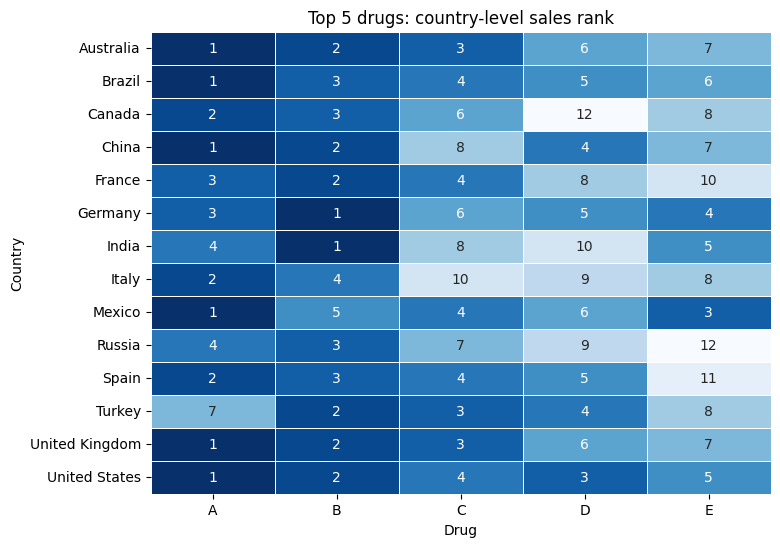

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Approximate data from the image
data = {
    "A":[1,1,2,1,3,3,4,2,1,4,2,7,1,1],
    "B":[2,3,3,2,2,1,1,4,5,3,3,2,2,2],
    "C":[3,4,6,8,4,6,8,10,4,7,4,3,3,4],
    "D":[6,5,12,4,8,5,10,9,6,9,5,4,6,3],
    "E":[7,6,8,7,10,4,5,8,3,12,11,8,7,5]
}

countries = [
    "Australia","Brazil","Canada","China","France","Germany",
    "India","Italy","Mexico","Russia","Spain","Turkey",
    "United Kingdom","United States"
]

df = pd.DataFrame(data, index=countries)

plt.figure(figsize=(8,6))

sns.heatmap(
    df,
    annot=True,
    cmap="Blues_r",
    linewidths=0.5,
    cbar=False
)

plt.title("Top 5 drugs: country-level sales rank")
plt.xlabel("Drug")
plt.ylabel("Country")

plt.show()